BPR function

# Weekly meeting
- [weekley meeting collection](https://github.com/jooneui/BPR/blob/main/.ipynb_checkpoints/Weekly_meeting_BPR_function-checkpoint.ipynb)

# Variable Definition 
- Need to check it again
- Time
    - $\bar{t}$: Average time to move unit distance (min/mile)
    - $t_0$: Free-flow travel time (min)
    - $T$: Given(??) time period (hr)

- Flow
    - $N$: Daily Traffic volume (vpd) ($= N_0 \times l$, $l$: The number of lanes)
    - $N_0$: Daily Traffic volume per lane (vpdpl)
    - $C$: Road capacity (vpd) ($= C_0 \times l$)
    - $C_0$: Road capacity per lane(vpdpl) = 32,000vpd
    - $\bar{C}$: Pratical capacity (vpd)
    - $q$: Flow rate per lane(vphpl)

- Speed
    - $\bar{v}$: Average speed(mph)
    - $\mu$: Free-flow speed(mph)
- Density
    - $k$: Density(vpm)
    - $k_c$: Critical density(vpm)
    - $k_j$: Jam density(vpm)
- Etc
    - $d$: Loop detector length(m)
    - $l$: The number of lanes

# Introduction

## The importance of Volume-Delay function(VDF)

- VDF is a critical component of traffic assignment, quantifying travel time caused by observed volume and road capacity(Kucharski and Drabicki 2017)
- VDF establishes the relationship between travel time, road traffic volume, and dynamic traffic state (Branston 1976; Nie and Zhang 2005; Patriksson 2015)
- Accurate estimation and calibration of the current traffic demand and supply are crucial in identifying and addressing congested or oversaturated conditions (Yuyan Pan et al. 2023)

## BPR function
- The Bureau of Public Roads (BPR), Davidson’s, Akcelik’s, and conical delay functions are the most commonly used link cost functions.
- The BPR function has profound applications in transportation planning primarily as a result of its simple mathematical form, easily observable field inputs, and consistent performance (Mtoi and Ren, 2014; Das and Rama Chilukuri, 2020)
- BPR function: $t=t_0(1+\alpha(\frac{N}{C})^\beta)$
    - $\alpha$ is the scale parameter
        - how the congestion effects change when the capacity is reached(Spiess, 1990)
    - $\beta$ is a shape parameter

## Problem Statement

- ① BPR has not adequately incorporated fundamental diagrams(FD)
    - BPR function
        - $\bar{t}=\frac{1}{\bar{v}}=t_0[1+\alpha(\frac{N}{C})^\beta]$ ($N=qT$)
    - Triangular F.D.
        - $\bar{t} = \begin{cases} \frac{1}{\mu} \text{  (if  } k < k_c) \\ \frac{Tk_j}{N} - \frac{1}{\omega} \text{  (if  } k > k_c) \end{cases}$ [Appendix 1]
    - Simply employing $N/C$ in the BPR fails to accurately depict the shape of FD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def BPR_function(t_0,C,alpha,beta,N):
    t =  t_0 * (1+alpha*(N/C)**beta)
    return t

def Triangular_FD_congested(q,k_j,w):
    t = (k_j/q-1/w)*60
    return t

Text(0.5, 1.0, 'BPR vs Triangular F.D.')

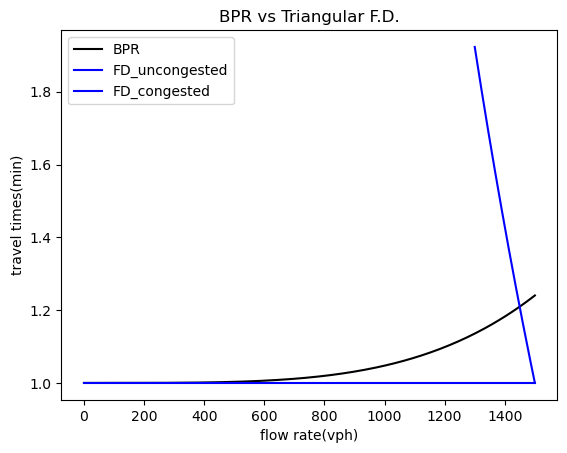

In [2]:
# 1. Variable Definition
# Unit: q:vph, C: vpd, k_j: vpm, mu: mph, tau: sec, w: vpm, t_0: min
q = np.linspace(0,1500,200)
q_c = np.linspace(1300,1500,200)
T = 24
N = q * T
C = 32000
k_j = 150
tau = 2 
mu = 60
w = 1/(tau * k_j)*3600
alpha = 0.15
beta = 4
t_0 = 1/mu*60

# 2. calculate the function value

t_BPR = BPR_function(t_0,C,alpha,beta,N)

t_FD_u = np.repeat(t_0,200)
t_FD_c = Triangular_FD_congested(q_c,k_j,w)

# 3. plot 
plt.plot(q,t_BPR, color='black',label = 'BPR')
plt.plot(q,t_FD_u, color='blue',label = 'FD_uncongested')
plt.plot(q_c,t_FD_c, color='blue',label = 'FD_congested')
plt.legend(fontsize = 10)
plt.xlabel('flow rate(vph)')
plt.ylabel('travel times(min)')
plt.title('BPR vs Triangular F.D.')

- ② Discrepancy with the original paper(BPR, 1964)
    - There are discrepancies in how variables are used between the original paper(BRP, 1964) and pratical application.
||BPR(1964)|Practical Usage|
|:------:|:------------------:|-------------------------|
|Expression|$t=t_0(1+\alpha(\frac{N}{\tilde{C}})^\beta)$|$t=t_0(1+\alpha(\frac{N}{C})^\beta)$|
|$N$|Assigned volume(vpd)| Daily Traffic volume(??) (vpd)   |
|$C$ or $\tilde{C}$|Practical capacity(vpd) $\approx 32,000vpd$| Road capacity(vpd)|
    
    - Practical capacity is much less than general road capacity, leading to a possible case of $N>C$
        - The original paper also addressed this case as an example.
    - However, in the measured data, it is impossible to directly observe the case where V/C is greater than 1.(Yuyan Pan et al. 2023)
- Therefore, it is necessary to redefine the demand-supply relation($N/C$) that resolves the both drawbacks of BPR
    - replacing the practical capacity with higher value does not resolve the first issue: The incorporation of FD into BPR
- <span style="color:red"> Q) I would like to discuss the interpretation of practical capacity($\tilde{C}$)</span>
    - <span style="color:red"> The practical capacity of 32,000vpd mentioned in BPR(1964) applies specifically to link 3403-3406. What if the link has only one lane? If then, the practical capacity varies based on the number of lanes in each link. For instance, a two-lane link may have a practical capacity of 64,000vp. I think this statement is more logical considering the varying road capacity depending on the number of lanes. </span>





## Objective

- Propose advanced BPR function by newly defining traffic demand
    - Traffic demand refers to the amount of vehicular or pedestrian traffic that is __expected or desired__ in a particular area or on a particular roadway
        - Measure of the need for transportation infrastructure
- Let's newly define traffic demand as $N'=q\cdot T(N)$, where $N'$ stands for desired trafffic volume and $w$ as road capacity(vph)
    - __$T(N)$: the intensity of demand__(이거 설명 필요)
    - <span style="color:red"> Q) What about using T(k) instead of T(N) as N itself cannot distinguish between hyper- and under-congested. </span> 
        - (ex. $T(N)=\frac{N}{q}$)
            - $N$: Traffic volume (vpd)
            - $q$: Annual average daily traffic (vph)
            - $T$: Observed time period (hr)
    - $w$: capacity(vpd?)
        - __How can we define it? As Wished time windows need to be handled in time windows??__(이거)
- Three cases for defining $N'$ 
    - All-day: $T(N)$=24 & w are similar during the normal weekdays
    - peak
    - non-peak
        - __Q) If $T(N)$ is a linear function of $N$, and $w$ is not function of $N$, how about plotting $N^2$ vs $\bar{z}$, and check if it follows BPR shape?__        
- 어떻게 할 수 있을까??
    - demand derivation 할 수 있을까?? 먼저 추세를 보자!!

## Appendix

- 1. Triangular Fundamental Diagram
    - $k \ge k_c$
        - $q = \omega(k_j-k)$
        - $k = k_j-\frac{q}{\omega}$
        - $v = \frac{q}{k}=\frac{\omega q}{\omega k_j - q}=\frac{\omega q}{\omega \times \frac{\mu+\omega}{\mu\omega}C-q}=\frac{\omega q}{\frac{\mu+\omega}{\mu}C-q}=\frac{\mu\omega q}{\mu(C-q)+wC}$
        - $z=\frac{1}{v}=\frac{\mu(C-q)+\omega C}{\mu \omega q}=\frac{C(\mu+\omega)}{\mu \omega q}-\frac{1}{\omega}=\frac{k_j}{q}-\frac{1}{\omega}$
        - cf) $\bar{z}=\frac{\int_0^T z(t)q(t) dt}{\int_0^T q dt}=\frac{\int_0^T k_j-\frac{q}{\omega}dt}{\int_0^T q dt}=\frac{k_j T - \frac{\bar{q}T}{\omega}}{\bar{q}T}=\frac{k_j}{\bar{q}}-\frac{1}{\omega}=\frac{Tk_j}{N}-\frac{1}{\omega}$
    - $k \lt k_c$
        - $v = \mu$
        - $z = \frac{1}{v}=\frac{1}{\mu}$
        

# Literature Review

- __Papers__
    - __Yuyan Annie Pan et al., 2023__
        - Background
            - Exisiting VDFs have not adequately incorporated fundamental diagrams(FD)
        - Objective
            - An improved VDF is proposed, based on the FD by integrating the traffic flow model into the VDF.
                - Only using one parameter $m$, refering to maximum flow inertia coefficient
            - The proposed VDF will be tested and validated in two cases: Beijing and LA
                - New model performs better than existing models with respect to RMSE and MAE
        - [Methodology](./Yuyan_Annie_Pan_2023.ipynb)
            - The hypercongested region of the FD experiences a left-right symmetric shift with $x=v/C=1$ as the reference point.
            - <center> <img src="https://github.com/jooneui/fig_collection/blob/main/Fig2.png?raw=true", width = 70%>
            - $tt= \begin{cases} t_0 \cdot [\frac{2}{1+\sqrt{1-(\frac{V}{C})^m}}]^{\frac{2}{m}}, \text{  if  } V/C \lt 1 \\  t_0 \cdot [\frac{2}{1-\sqrt{1-(2-\frac{V}{C})^m}}]^\frac{2}{m}, \text{  if  } V/C > 1 \end{cases}$
- BPR drawbacks
    - fails to accurately capture the dynamics of traffic flow (Pan et al., 2022) and queue evolution(Cheng et al. 2022; Zhou et al. 2022)
    - its accuaracy decreases with higher values of $\beta$(Spiess 1990)
- Other VDFs
    - Davidson(1966, 1978): based on queueing theory
    - Akcelik(1979,1991): linear extension of Davidson's function
    - Tisato(1991): modified version Davidson's model, addressing congestion duration during oversaturated conditions
    - Spiess(1990): canonical function
    - Zhou et al.(2022): improved version of Spiess

# Methodology
## Flow chart
- <span style="color:red"> Q) For the raw data, I use $q$ to represent flow rates and $\bar{v}$ to denote the average velocity of vehicles. I would like to discuss its appropriateness. </span>
- <span style="color:red"> I need to add steps for the Peak/Non-peak cases </span>

<center> <img src="https://github.com/jooneui/fig_collection/blob/main/Fig1.png?raw=true", width = "70%"> </center>

# Data Description
- Lane information(ex. HOT)
    - NO HOT, but only HOV.
    - VDS does not cover the HOV lane, but only for general-purpose lanes(4 out of 5 lanes).
    - HOT in SR 91: SR 91 with the SR 55 Freeway (Costa Mesa Freeway) in Anaheim to its junction with I-15 in Corona(18 miles)
      
    <center> <img src="https://ars.els-cdn.com/content/image/1-s2.0-S0191261517311050-gr9.jpg", width = 40%> </center>
- Check consistency with Qinglong Yan et al.(2018); critical density, free-flow speed, etc.
    - Yan et al. 2018. 
        - Nine months (Jan., Feb., Mar., Apr., May, July, Sept., Oct., and Nov.) in 2011 with the sample size of 273 days
        - 30sec data
        - Using flow-rate and occupancy
        - Critical occ: 0.164




# Results
- __All-day case__
    - The current outcome doesn't exhibit a clear pattern and doesn't appear to resemble the shape of a BPR function. 
To grasp the overall shape of the results, additional data with a different rang is required
- __Plan to analysis__
    - ①  The datasets from August 2019, September 2019, October 2023, and November 2023 exhibit minimal variance
         - The Average Annual Daily Traffic (AADT) from 2019 to 2023 remains stable
        - It is essential to include datasets from a different time frame, specifically the 2014-2015 dataset
        - Comparatively, the demand during 2014-2015 was significantly higher than that of 2019-2023
    - ② The rawdata with different timeframe(15min, 1hour) needs to be applied.
    
- <center> <img src="https://github.com/jooneui/fig_collection/blob/main/AADT_2013-2024.png?raw=true", width = "80%"> </center>

In [2]:
def detect_twopeak(time_frame_peak, time_frame, rawdata, lane_num, gfactor, height, width):
    
    num_frame = time_frame_peak/time_frame
    traffic_day = pd.DataFrame({'speed':[],'time':[],'flow':[],'density':[]})
    
    # Step 0: uploading data and unifying rawdata's format
    plot_date = []

    # Step 1: variable setting(time_frame: min, lane_num: range of lanes for analysis)
    for hour in range(0, 24):
        for minute in range(0, int(60/time_frame_peak)):
            start_time = hour*100 + minute*time_frame_peak
            end_time = start_time + time_frame_peak
            # Filter rawdata for the current time slot
            mask = (rawdata['time_filter'] >= start_time) & (rawdata['time_filter'] < end_time)
            rawdata_filter = rawdata[mask]
    
            if not rawdata_filter.empty:
                # Compute average traffic state and append to traffic_day
                avg_speed, avg_time, avg_flow, avg_density = avg_traffic_state(rawdata_filter, time_frame, lane_num, gfactor)
                traffic_day.loc[len(traffic_day)] = [avg_speed, avg_time, avg_flow, avg_density]
    
    peaks, _ = find_peaks(traffic_day['flow'], height=height, width=width)  # Adjust `height` and `prominence` as needed
    # print(peaks)
    return len(peaks)

In [ ]:
# Detect if the data has two peaks
two_peak_dates = []

for i, file_name in enumerate(file_list):
    # 15min
    time_frame_peak = 30
    num_frame = time_frame_peak/raw_timeframe
    
    traffic_day = pd.DataFrame({'speed':[],'time':[],'flow':[],'density':[]})
    height = 1500; distance = 8
    # Step 0: uploading data and unifying rawdata's format
    date = file_name[-11:]
    rawdata = rawdata_setting(directory,file_name)
    gfactor = pd.read_excel(f'{path}/gfactor/gfactor_{date}')
    
    peak_len = detect_twopeak(time_frame_peak, raw_timeframe, rawdata, lane_num, gfactor, height, distance)
    if peak_len >= 2:
        two_peak_dates.append(file_name)

In [6]:
# Check the relationship between flow and time for the entire period

# Step 0: Create an empty DataFrame to store daily traffic data and set basic variables
# traffic_day = pd.DataFrame({'speed': [], 'time': [], 'flow': [], 'density': [],'year':[],'day':[]})

# option: 'two-peak_days', 'entire days', ;filterd days"
dataset_days = 'filtered days'
# label_criterion: 'year', 'day'
label_criterion = 'day'
# lane range: 'all lanes' '1,2 lanes'
lane_range = 'all lanes'
year_range = ['2011','2014','2015','2024']

if (dataset_days == 'entire days'):
    Dataset = file_list
elif(dataset_days == 'two-peak days'):
    Dataset = two_peak_dates
else:
    Dataset = filtered_dates
    
for i, file_name in enumerate(Dataset):
    # Step 1: Load data for each day and process it
    # Load raw data from csv file
    rawdata = rawdata_setting(directory,file_name,total_lane_raw)
    date = file_name[-11:]
    year = f'20{date[0:2]}'
    Day_list = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    Day = Day_list[int(rawdata.loc[0,'time'].weekday())]
    
#     gfactor = pd.read_excel(f'{path}/gfactor/gfactor_{date}')

#     # Step 2: Calculate the average traffic state for the day
#     avg_speed, avg_time, avg_flow, avg_density = avg_traffic_state(rawdata, raw_timeframe, lane_num, gfactor)

#     # Append daily traffic state to the DataFrame
#     traffic_day.loc[i] = [avg_speed, avg_time, avg_flow, avg_density, year, Day]

# with open(f'traffic_day_{dataset_days}_{lane_range}.p', 'wb') as file:  
#     pickle.dump(traffic_day, file)

with open(f'traffic_day_{dataset_days}_{lane_range}.p', 'rb') as file:
    traffic_day = pickle.load(file)
    
traffic_day = traffic_day.iloc[np.where(traffic_day['year'].isin(year_range))]
print(traffic_day)   

traffic_day = traffic_day.iloc[np.where(traffic_day['day'].isin(['Sat','Sun','Fri']))]

# Step 3: Create a scatter plot for 'flow' vs 'time'
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

traffic_day.loc[traffic_day['day'].isin(['Tue','Wed','Thu']), 'day'] = 'Tue~Thu'
traffic_day = traffic_day.groupby(label_criterion)

for name, group in traffic_day:
    ax.plot(group["flow"], group["time"], marker="o", linestyle="", label=f"{name}")
    
plt.legend()

ax.set_title(f'Relationship between Daily Flow and Traveling Time at {lane_range} during {dataset_days}')
ax.set_ylabel('Traveling Time (min/mile)', fontsize=13)
ax.set_xlabel('Flow Rates(vphpl)', fontsize=13)
ax.grid(True)
ax.set_xlim([600,1800])
ax.set_ylim([0,2])
ax.legend(title=f'{label_criterion}')

# Save and Display the plot
# plt.savefig(f'./02 fig/12 Daily/Daily_flow_vs_time_{lane_range}_{dataset_days}({year_range})_labeled by_{label_criterion}.png')
plt.show()

NameError: name 'Dataset' is not defined

In [ ]:
x = [0, 1.6, 1.7, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 5, 5, 6, 7]
# peaks, properties = find_peaks(x, distance=5, plateau_size=2)

peaks, properties = find_peaks(x,height=2,distance=1)
# , width=5
print(peaks)
print(properties)